In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%config InlineBackend.figure_format = 'retina'

In [2]:
DATA = Path("../Data")
BUFFERS = [50, 100, 500, 1000, 5000, 10000, 50000]
SITES = ["Boquillas", "CharlestonMesquite", "Contention", "Fairbank", "Hereford", "Hunter", "Moson", "St.David"]

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

flow = pd.read_csv(DATA / "USPPFlowMonitoring2006_2025.csv")
cameras = flow.groupby("Site")[["Latitude", "Longitude"]].first().dropna()

towers = pd.DataFrame(
    {
        "tower": ["CMW", "LS1", "LS2"],
        "latitude": [31.6637, 31.5615, 31.5659],
        "longitude": [-110.1777, -110.1403, -110.1344],
    }
).set_index("tower")

In [4]:
mapping_rows = []
tower_to_site = {}
for tower, row in towers.iterrows():
    distances = haversine(row.latitude, row.longitude, cameras["Latitude"], cameras["Longitude"])
    nearest_site = distances.idxmin()
    mapping_rows.append({"Tower": tower, "Nearest Site": nearest_site, "Distance (km)": distances.min()})
    tower_to_site[tower] = nearest_site

tower_site_map = pd.DataFrame(mapping_rows).set_index("Tower")
tower_site_map

,Nearest Site,Distance (km)
Tower,,
CMW,CharlestonMesquite,0.263696
LS1,Moson,6.099048
LS2,Moson,5.927532


In [5]:
def smallest_buffer(site, product):
    for buf in BUFFERS:
        f = DATA / "ET" / f"ET_{site}buffer{buf}{product}.csv"
        if f.exists() and pd.read_csv(f)["ET"].notna().any():
            return buf
    return np.nan

buffer_table = pd.DataFrame(
    {product: [smallest_buffer(site, product) for site in SITES] for product in ["MODIS", "OpenET", "PML"]},
    index=SITES,
)
buffer_table

,MODIS,OpenET,PML
Boquillas,50,NaN,50
CharlestonMesquite,50,50000.0,50
Contention,50,50000.0,50
Fairbank,50,50000.0,50
Hereford,50,50.0,50
Hunter,50,50.0,50
Moson,50,50.0,50
St.David,50,NaN,50


In [6]:
ec = pd.read_csv(DATA / "Eddy_covariance" / "allsites_EC.csv")
ec["datetime"] = pd.to_datetime(ec["datetime"])
ec = ec.set_index("datetime")

ec_towers = pd.DataFrame({
    "CMW": ec["CMW_BASE"].combine_first(ec["CMW_FLUXNET_2001"]),
    "LS1": ec["LS1_BASE"].combine_first(ec["LS1_FLUXNET_2003"]),
    "LS2": ec["LS2_BASE"],
})
ec_daily = ec_towers.resample("D").mean() # aggregate sub-daily data

In [7]:
def period_average(daily, period_dates):
    period_dates = pd.to_datetime(pd.Series(period_dates).reset_index(drop=True))
    sorted_dates = period_dates.sort_values().reset_index(drop=True)
    edges = pd.concat([sorted_dates, pd.Series([sorted_dates.iloc[-1] + pd.Timedelta(days=8)])], ignore_index=True)
    bins = pd.cut(daily.index, bins=edges, right=False, labels=sorted_dates)
    grouped = daily.groupby(bins, observed=True).mean()
    grouped.index = pd.to_datetime(grouped.index)
    return period_dates.map(grouped)

In [8]:
products = {}
for tower, site in tower_to_site.items():
    ec_series = ec_daily[tower].dropna()

    modis_buffer = int(buffer_table.loc[site, "MODIS"])
    modis = pd.read_csv(DATA / "ET" / f"ET_{site}buffer{modis_buffer}MODIS.csv")
    modis["Date"] = pd.to_datetime(modis["Date"])
    modis["EC"] = period_average(ec_series, modis["Date"]).to_numpy()

    pml_buffer = int(buffer_table.loc[site, "PML"])
    pml = pd.read_csv(DATA / "ET" / f"ET_{site}buffer{pml_buffer}PML.csv")
    pml["Date"] = pd.to_datetime(pml["Date"])
    pml["EC"] = period_average(ec_series, pml["Date"]).to_numpy()

    openet_buffer = int(buffer_table.loc[site, "OpenET"])
    openet = pd.read_csv(DATA / "ET" / f"ET_{site}buffer{openet_buffer}OpenET.csv")
    openet["Date"] = pd.to_datetime(openet["Date"])
    openet["EC"] = ec_series.resample("ME").mean().reindex(openet["Date"]).to_numpy()

    pmdl = pd.read_csv(DATA / "Jawad_ET" / "J.csv")
    pmdl["date"] = pd.to_datetime(pmdl["date"])
    pmdl = pmdl[pmdl["Site"] == site][["date", "ET"]].rename(columns={"date": "Date"})
    pmdl["EC"] = ec_series.reindex(pmdl["Date"]).to_numpy()

    products[tower] = {"MODIS": modis, "OpenET": openet, "PML": pml, "PMDL": pmdl}

In [9]:
records = []
for tower, prods in products.items():
    for product, df in prods.items():
        paired = df[["EC", "ET"]].dropna()
        if len(paired) < 3:
            continue
        pearson_r, pearson_p = stats.pearsonr(paired["EC"], paired["ET"])
        spearman_r, spearman_p = stats.spearmanr(paired["EC"], paired["ET"])
        records.append({
            "Tower": tower,
            "Product": product,
            "n": len(paired),
            "Pearson r": pearson_r,
            "Pearson p": pearson_p,
            "Spearman rho": spearman_r,
        })

correlations = pd.DataFrame(records).sort_values(["Tower", "Pearson r"], ascending=[True, False])
correlations

,Tower,Product,n,Pearson r,Pearson p,Spearman rho
1,CMW,OpenET,250,0.827691,3.661490e-64,0.807921
2,CMW,PML,953,0.800848,5.630466e-214,0.819344
3,CMW,PMDL,6209,0.585043,0.000000e+00,0.828700
0,CMW,MODIS,953,0.559358,1.488226e-79,0.555108
5,LS1,OpenET,60,0.932702,2.282695e-27,0.920978
6,LS1,PML,227,0.691601,1.236585e-33,0.703963
7,LS1,PMDL,1095,0.530511,1.633749e-80,0.820629
4,LS1,MODIS,227,0.410836,1.176060e-10,0.334248
9,LS2,OpenET,58,0.912451,2.146852e-23,0.876157
10,LS2,PML,220,0.750132,5.020598e-41,0.761140


In [10]:
best_per_tower = correlations.loc[correlations.groupby("Tower")["Pearson r"].idxmax()]
print(best_per_tower[["Tower", "Product", "Pearson r", "n"]].to_string(index=False))

overall = correlations.groupby("Product")["Pearson r"].mean().sort_values(ascending=False)
print()
print("Average Pearson r across towers by product:")
print(overall.round(3))

Tower Product  Pearson r   n
  CMW  OpenET   0.827691 250
  LS1  OpenET   0.932702  60
  LS2  OpenET   0.912451  58

Average Pearson r across towers by product:
Product
OpenET    0.891
PML       0.748
PMDL      0.593
MODIS     0.485
Name: Pearson r, dtype: float64


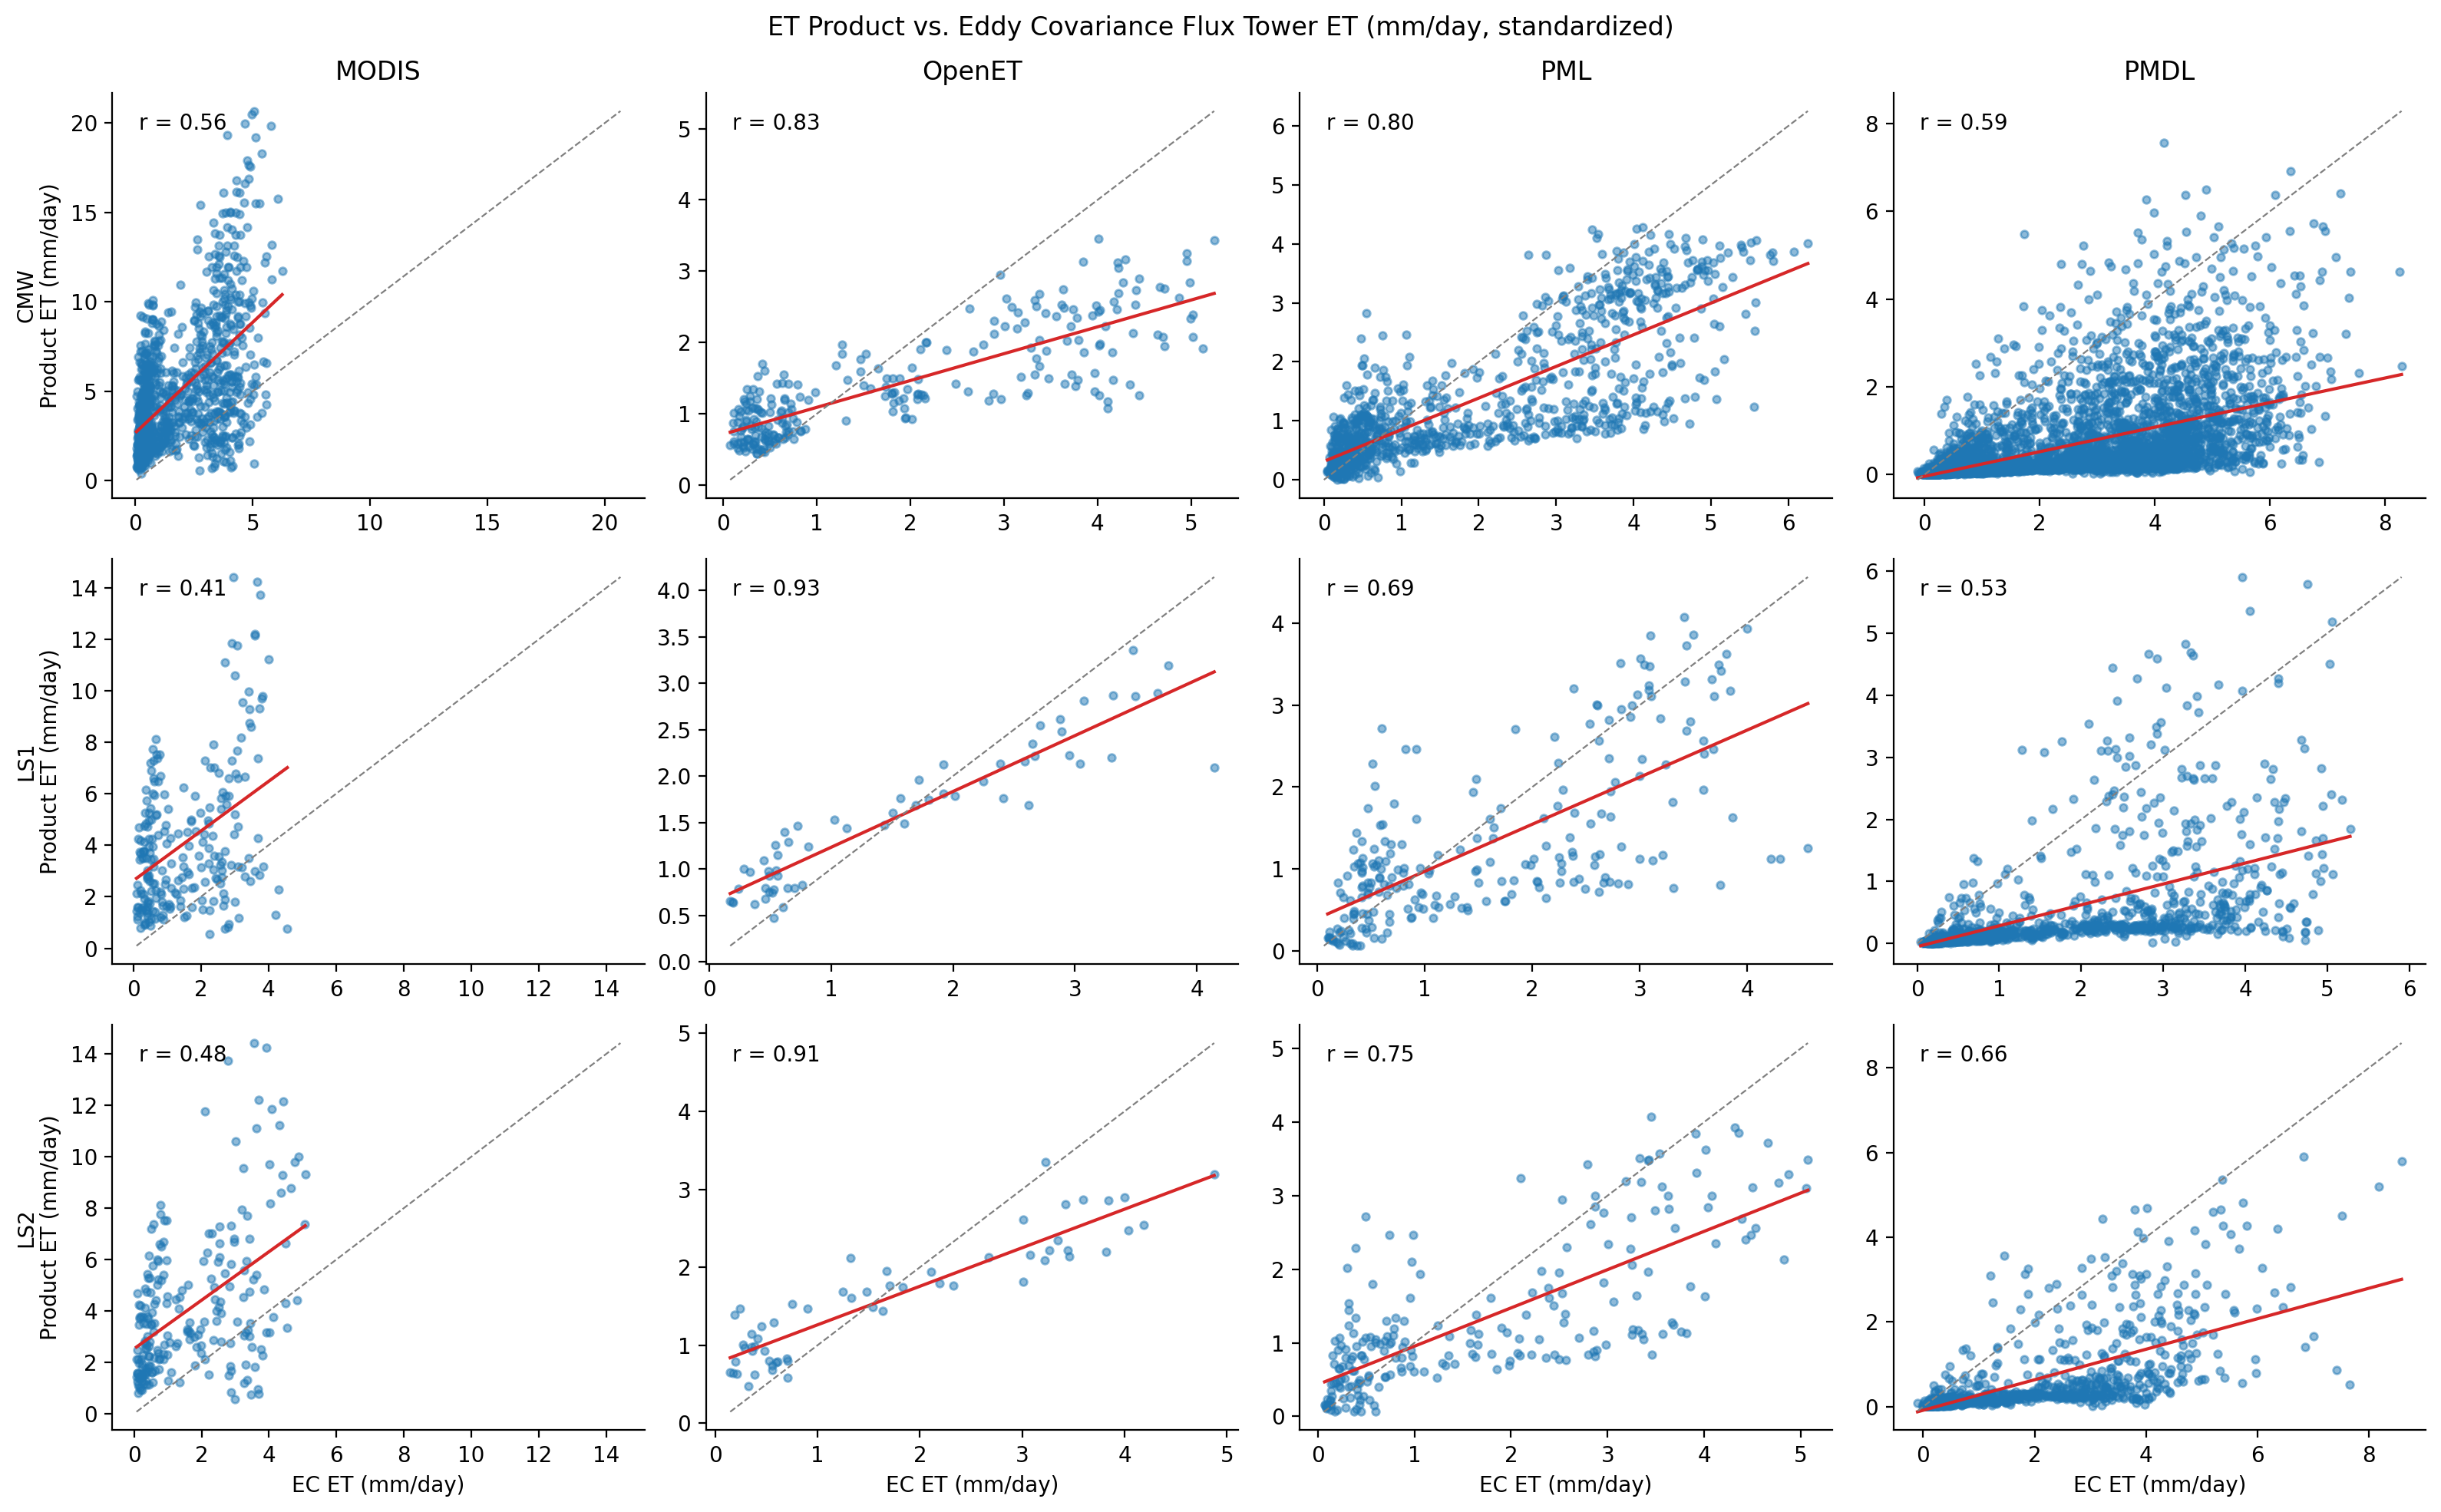

In [11]:
product_order = ["MODIS", "OpenET", "PML", "PMDL"]

def to_daily_rate(df, product):
    if product in ("MODIS", "PML"):
        return df["ET"] / 8
    if product == "OpenET":
        return df["ET"] / df["Date"].dt.days_in_month
    return df["ET"]

fig, axes = plt.subplots(len(products), len(product_order), figsize=(16, 10), squeeze=False)
for i, tower in enumerate(products):
    for j, product in enumerate(product_order):
        ax = axes[i, j]
        df = products[tower][product]
        paired = pd.DataFrame({"EC": df["EC"], "ET": to_daily_rate(df, product)}).dropna()
        ax.scatter(paired["EC"], paired["ET"], s=12, alpha=0.5, color="tab:blue")
        if len(paired) >= 3:
            slope, intercept, r, p, se = stats.linregress(paired["EC"], paired["ET"])
            x_line = np.linspace(paired["EC"].min(), paired["EC"].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color="tab:red")
            lims = [min(paired["EC"].min(), paired["ET"].min()), max(paired["EC"].max(), paired["ET"].max())]
            ax.plot(lims, lims, color="gray", linestyle="--", linewidth=0.8)
            ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes, va="top")
        if i == 0:
            ax.set_title(product)
        if j == 0:
            ax.set_ylabel(f"{tower}\nProduct ET (mm/day)")
        if i == len(products) - 1:
            ax.set_xlabel("EC ET (mm/day)")
        ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("ET Product vs. Eddy Covariance Flux Tower ET (mm/day, standardized)")
fig.tight_layout()

In [12]:
products_50000 = {}
for tower, site in tower_to_site.items():
    ec_series = ec_daily[tower].dropna()

    modis = pd.read_csv(DATA / "ET" / f"ET_{site}buffer50000MODIS.csv")
    modis["Date"] = pd.to_datetime(modis["Date"])
    modis["EC"] = period_average(ec_series, modis["Date"]).to_numpy()

    pml = pd.read_csv(DATA / "ET" / f"ET_{site}buffer50000PML.csv")
    pml["Date"] = pd.to_datetime(pml["Date"])
    pml["EC"] = period_average(ec_series, pml["Date"]).to_numpy()

    openet = pd.read_csv(DATA / "ET" / f"ET_{site}buffer50000OpenET.csv")
    openet["Date"] = pd.to_datetime(openet["Date"])
    openet["EC"] = ec_series.resample("ME").mean().reindex(openet["Date"]).to_numpy()

    pmdl = pd.read_csv(DATA / "Jawad_ET" / "J.csv")
    pmdl["date"] = pd.to_datetime(pmdl["date"])
    pmdl = pmdl[pmdl["Site"] == site][["date", "ET"]].rename(columns={"date": "Date"})
    pmdl["EC"] = ec_series.reindex(pmdl["Date"]).to_numpy()

    products_50000[tower] = {"MODIS": modis, "OpenET": openet, "PML": pml, "PMDL": pmdl}

In [13]:
records_50000 = []
for tower, prods in products_50000.items():
    for product, df in prods.items():
        paired = df[["EC", "ET"]].dropna()
        if len(paired) < 3:
            continue
        pearson_r, pearson_p = stats.pearsonr(paired["EC"], paired["ET"])
        spearman_r, spearman_p = stats.spearmanr(paired["EC"], paired["ET"])
        records_50000.append({
            "Tower": tower,
            "Product": product,
            "n": len(paired),
            "Pearson r": pearson_r,
            "Pearson p": pearson_p,
            "Spearman rho": spearman_r,
        })

correlations_50000 = pd.DataFrame(records_50000).sort_values(["Tower", "Pearson r"], ascending=[True, False])
correlations_50000

,Tower,Product,n,Pearson r,Pearson p,Spearman rho
1,CMW,OpenET,250,0.827691,3.661490e-64,0.807921
2,CMW,PML,953,0.715430,2.946368e-150,0.675714
3,CMW,PMDL,6209,0.585043,0.000000e+00,0.828700
0,CMW,MODIS,953,0.380083,4.071227e-34,0.314886
5,LS1,OpenET,60,0.862593,8.237588e-19,0.888080
6,LS1,PML,227,0.607732,2.603531e-24,0.575663
7,LS1,PMDL,1095,0.530511,1.633749e-80,0.820629
4,LS1,MODIS,227,0.233968,3.778529e-04,0.117137
9,LS2,OpenET,58,0.871041,6.230562e-19,0.837276
10,LS2,PML,220,0.673193,2.118153e-30,0.637635


In [14]:
best_per_tower_50000 = correlations_50000.loc[correlations_50000.groupby("Tower")["Pearson r"].idxmax()]
print(best_per_tower_50000[["Tower", "Product", "Pearson r", "n"]].to_string(index=False))

overall_50000 = correlations_50000.groupby("Product")["Pearson r"].mean().sort_values(ascending=False)
print()
print("Average Pearson r across towers by product (buffer = 50,000 m):")
print(overall_50000.round(3))

Tower Product  Pearson r   n
  CMW  OpenET   0.827691 250
  LS1  OpenET   0.862593  60
  LS2  OpenET   0.871041  58

Average Pearson r across towers by product (buffer = 50,000 m):
Product
OpenET    0.854
PML       0.665
PMDL      0.593
MODIS     0.314
Name: Pearson r, dtype: float64


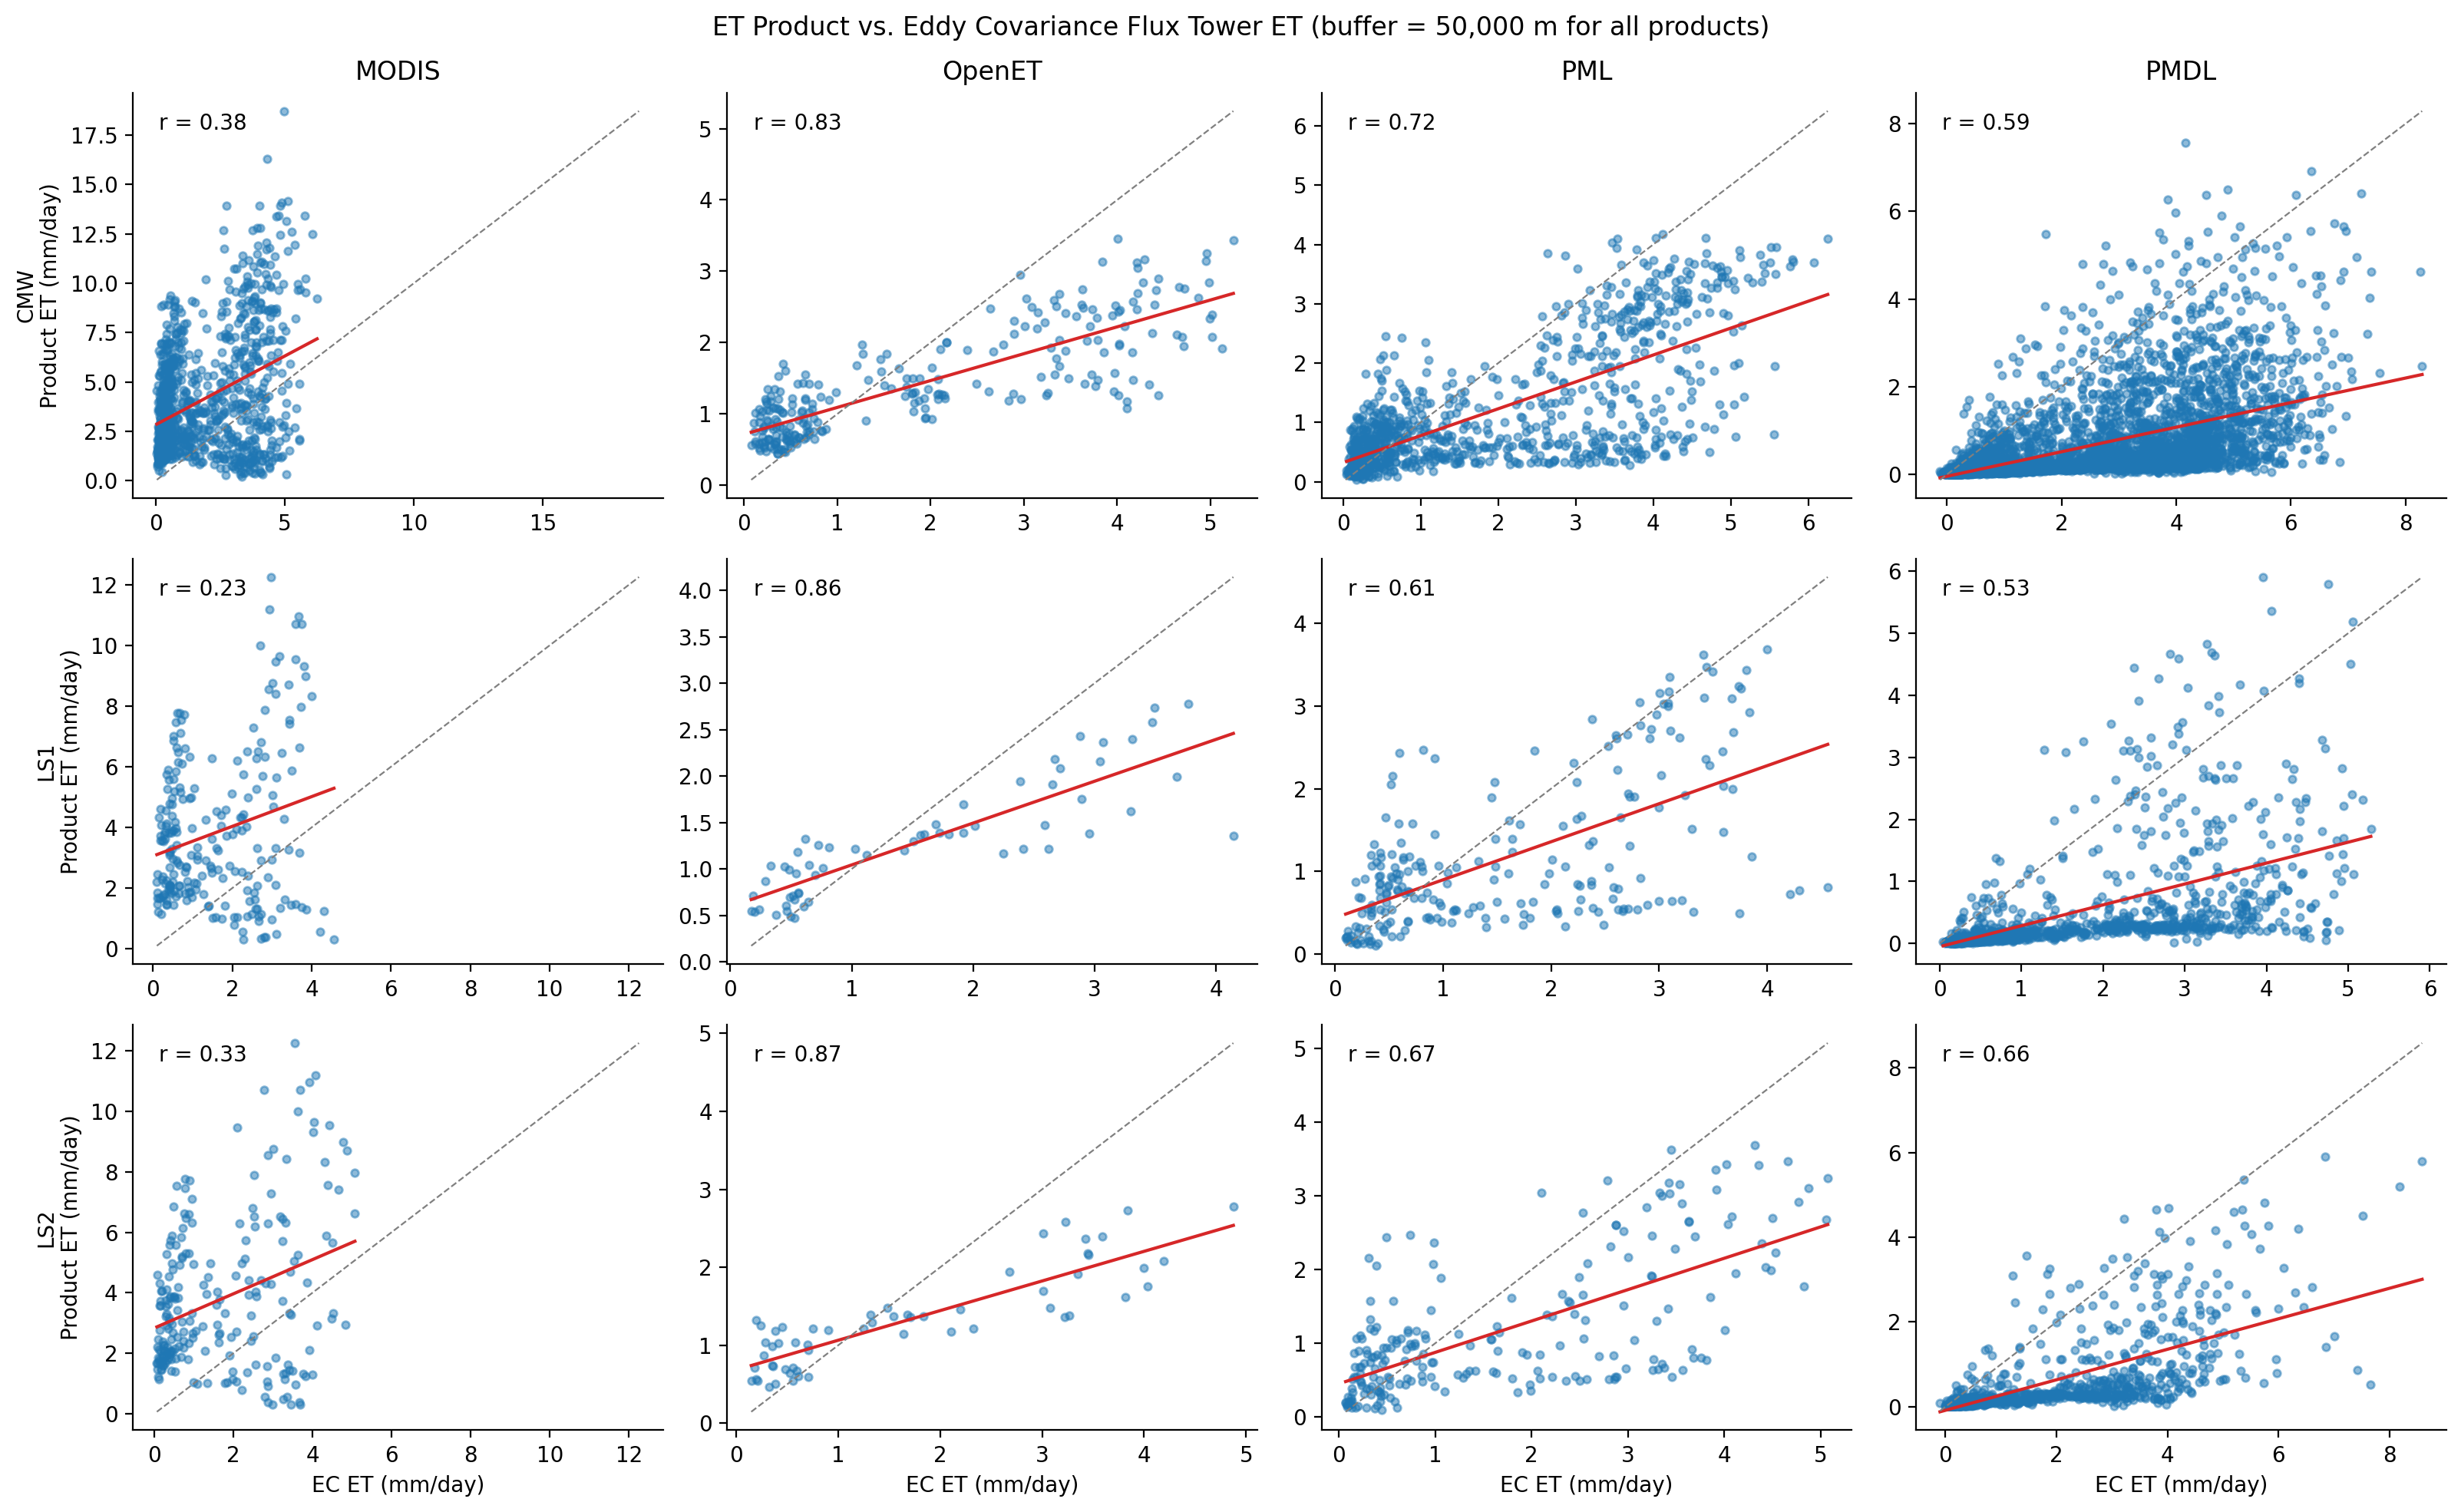

In [15]:
fig, axes = plt.subplots(len(products_50000), len(product_order), figsize=(16, 10), squeeze=False)
for i, tower in enumerate(products_50000):
    for j, product in enumerate(product_order):
        ax = axes[i, j]
        df = products_50000[tower][product]
        paired = pd.DataFrame({"EC": df["EC"], "ET": to_daily_rate(df, product)}).dropna()
        ax.scatter(paired["EC"], paired["ET"], s=12, alpha=0.5, color="tab:blue")
        if len(paired) >= 3:
            slope, intercept, r, p, se = stats.linregress(paired["EC"], paired["ET"])
            x_line = np.linspace(paired["EC"].min(), paired["EC"].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color="tab:red")
            lims = [min(paired["EC"].min(), paired["ET"].min()), max(paired["EC"].max(), paired["ET"].max())]
            ax.plot(lims, lims, color="gray", linestyle="--", linewidth=0.8)
            ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes, va="top")
        if i == 0:
            ax.set_title(product)
        if j == 0:
            ax.set_ylabel(f"{tower}\nProduct ET (mm/day)")
        if i == len(products_50000) - 1:
            ax.set_xlabel("EC ET (mm/day)")
        ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("ET Product vs. Eddy Covariance Flux Tower ET (buffer = 50,000 m for all products)")
fig.tight_layout()

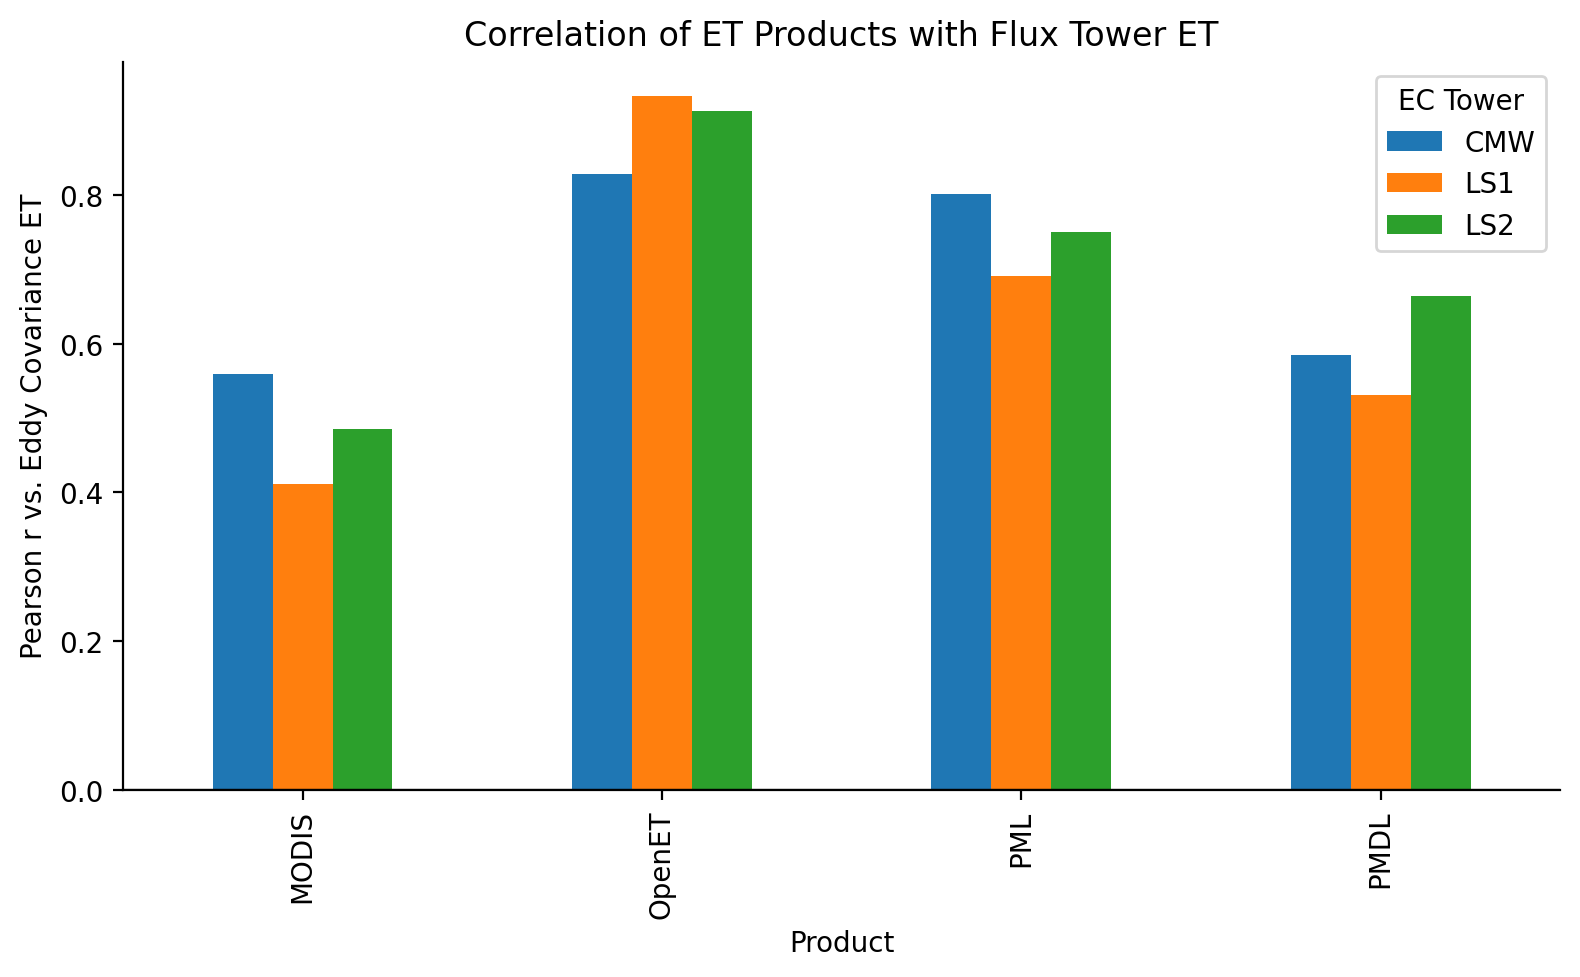

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = correlations.pivot(index="Product", columns="Tower", values="Pearson r").reindex(product_order)
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Pearson r vs. Eddy Covariance ET")
ax.set_title("Correlation of ET Products with Flux Tower ET")
ax.axhline(0, color="black", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="EC Tower")
fig.tight_layout()

In [17]:
def monthly_total_from_rate(daily_series, min_completeness=0.5):
    monthly_mean = daily_series.resample("ME").mean()
    valid_counts = daily_series.resample("ME").count()
    days_in_month = monthly_mean.index.days_in_month
    completeness = valid_counts / days_in_month
    return (monthly_mean * days_in_month).where(completeness >= min_completeness)

def monthly_total_from_periods(period_series):
    return period_series.resample("ME").sum(min_count=1)

In [18]:
ec_monthly_totals = {tower: monthly_total_from_rate(ec_daily[tower].dropna()) for tower in tower_to_site}

monthly_records = []
for tower, prods in products.items():
    ec_m = ec_monthly_totals[tower]
    for product in product_order:
        series = prods[product].set_index("Date")["ET"]
        if product == "OpenET":
            prod_m = series
        elif product == "PMDL":
            prod_m = monthly_total_from_rate(series)
        else:
            prod_m = monthly_total_from_periods(series)
        paired = pd.DataFrame({"EC": ec_m, "prod": prod_m}).dropna()
        if len(paired) < 3:
            continue
        r, p = stats.pearsonr(paired["EC"], paired["prod"])
        monthly_records.append({"Tower": tower, "Product": product, "n": len(paired), "Pearson r": r})

correlations_monthly = pd.DataFrame(monthly_records).sort_values(["Tower", "Pearson r"], ascending=[True, False])
correlations_monthly

,Tower,Product,n,Pearson r
2,CMW,PML,249,0.843616
1,CMW,OpenET,249,0.830333
3,CMW,PMDL,204,0.819019
0,CMW,MODIS,249,0.622362
5,LS1,OpenET,59,0.933997
7,LS1,PMDL,36,0.803036
6,LS1,PML,59,0.745077
4,LS1,MODIS,59,0.465498
9,LS2,OpenET,57,0.913120
11,LS2,PMDL,35,0.872260


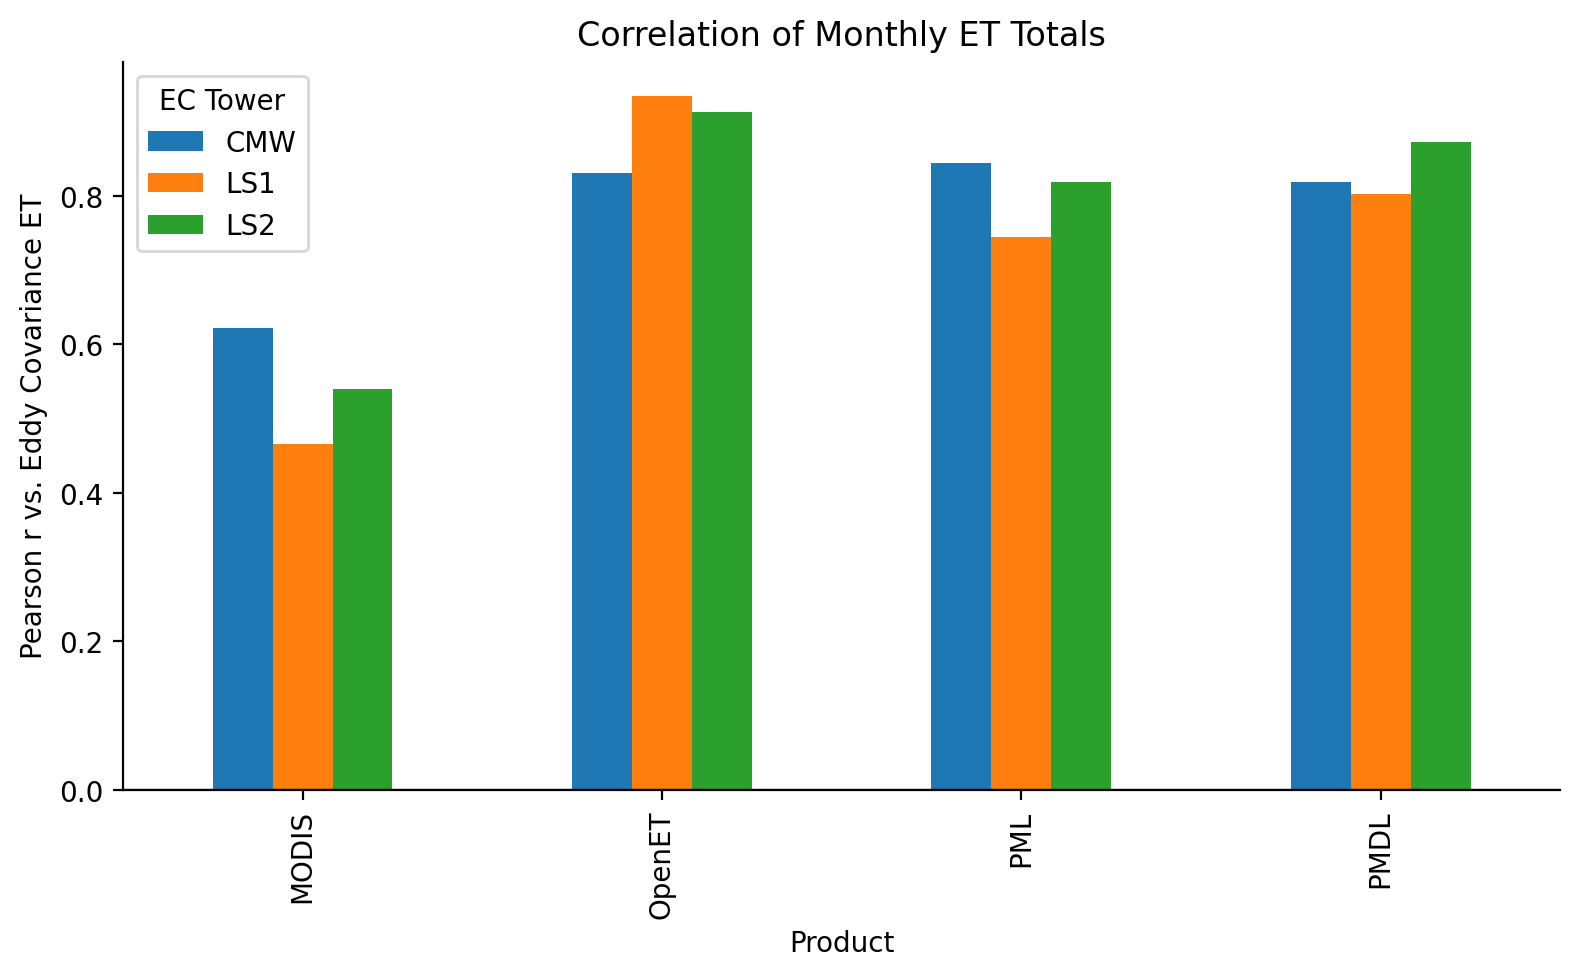

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot_monthly = correlations_monthly.pivot(index="Product", columns="Tower", values="Pearson r").reindex(product_order)
pivot_monthly.plot(kind="bar", ax=ax)
ax.set_ylabel("Pearson r vs. Eddy Covariance ET")
ax.set_title("Correlation of Monthly ET Totals")
ax.axhline(0, color="black", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="EC Tower")
fig.tight_layout()

In [20]:
monthly_records_50000 = []
for tower, prods in products_50000.items():
    ec_m = ec_monthly_totals[tower]
    for product in product_order:
        series = prods[product].set_index("Date")["ET"]
        if product == "OpenET":
            prod_m = series
        elif product == "PMDL":
            prod_m = monthly_total_from_rate(series)
        else:
            prod_m = monthly_total_from_periods(series)
        paired = pd.DataFrame({"EC": ec_m, "prod": prod_m}).dropna()
        if len(paired) < 3:
            continue
        r, p = stats.pearsonr(paired["EC"], paired["prod"])
        monthly_records_50000.append({"Tower": tower, "Product": product, "n": len(paired), "Pearson r": r})

correlations_monthly_50000 = pd.DataFrame(monthly_records_50000).sort_values(["Tower", "Pearson r"], ascending=[True, False])
correlations_monthly_50000

,Tower,Product,n,Pearson r
1,CMW,OpenET,249,0.830333
3,CMW,PMDL,204,0.819019
2,CMW,PML,249,0.765200
0,CMW,MODIS,249,0.444723
5,LS1,OpenET,59,0.864116
7,LS1,PMDL,36,0.803036
6,LS1,PML,59,0.664722
4,LS1,MODIS,59,0.277802
11,LS2,PMDL,35,0.872260
9,LS2,OpenET,57,0.870907


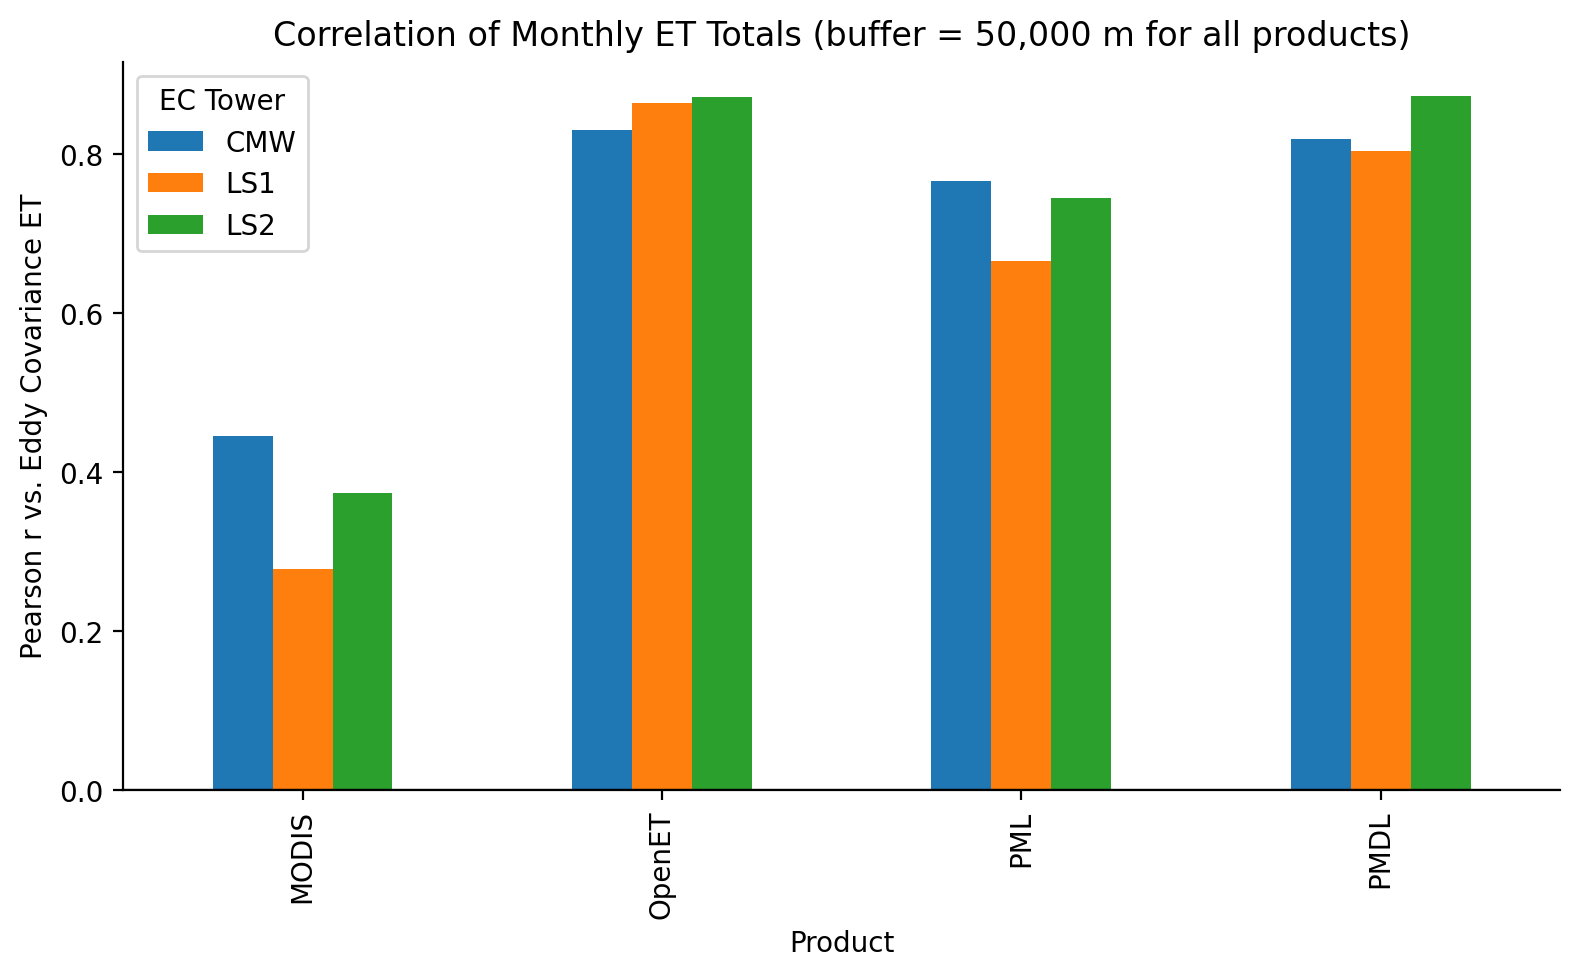

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot_monthly_50000 = correlations_monthly_50000.pivot(index="Product", columns="Tower", values="Pearson r").reindex(product_order)
pivot_monthly_50000.plot(kind="bar", ax=ax)
ax.set_ylabel("Pearson r vs. Eddy Covariance ET")
ax.set_title("Correlation of Monthly ET Totals (buffer = 50,000 m for all products)")
ax.axhline(0, color="black", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="EC Tower")
fig.tight_layout()

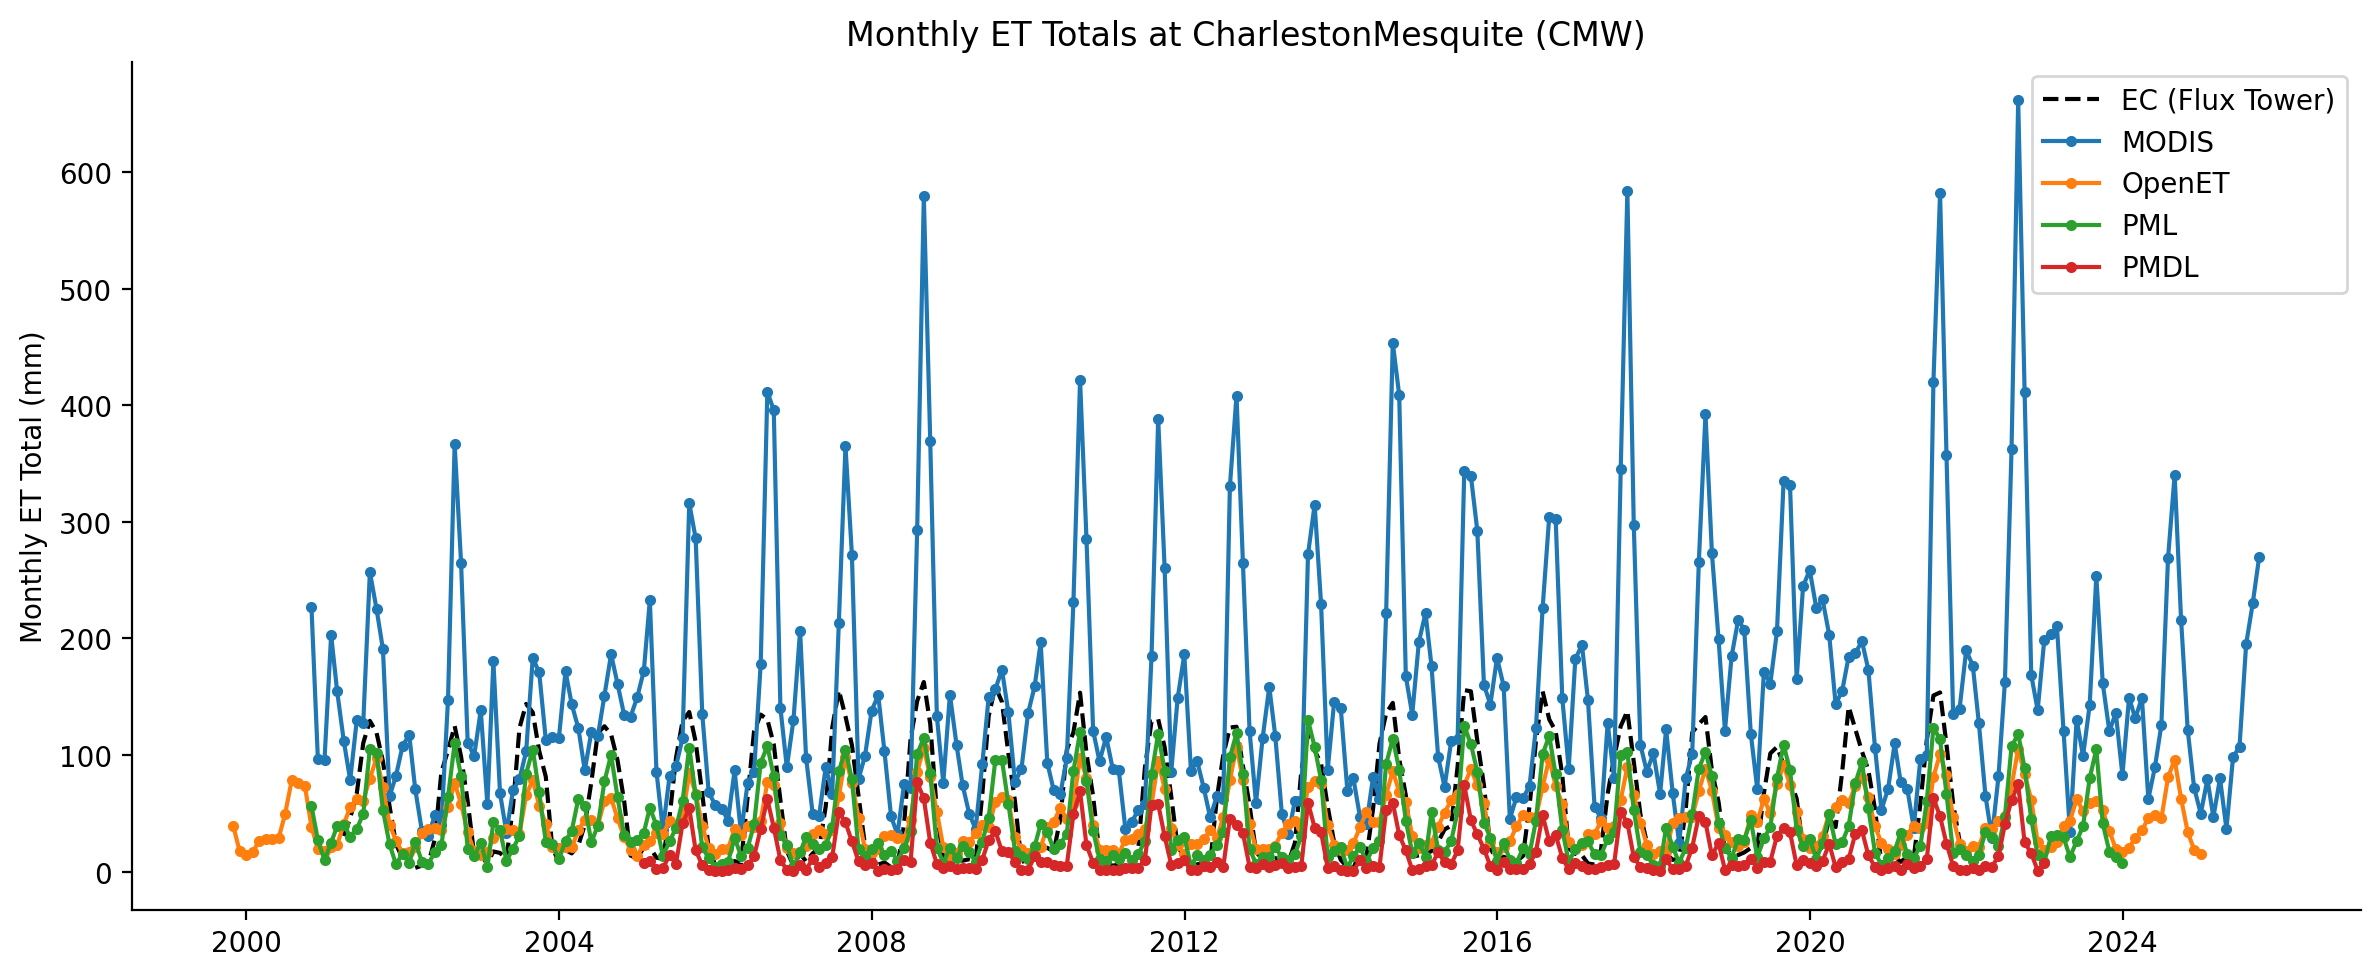

In [22]:
cmw_site = tower_to_site["CMW"]
cmw_products = products["CMW"]
ec_monthly_total = monthly_total_from_rate(ec_daily["CMW"].dropna())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ec_monthly_total.index, ec_monthly_total, color="black", linestyle="--", label="EC (Flux Tower)")
for product in product_order:
    series = cmw_products[product].set_index("Date")["ET"]
    if product == "OpenET":
        monthly_total = series
    elif product == "PMDL":
        monthly_total = monthly_total_from_rate(series)
    else:
        monthly_total = monthly_total_from_periods(series)
    ax.plot(monthly_total.index, monthly_total, marker="o", markersize=3, label=product)
ax.set_ylabel("Monthly ET Total (mm)")
ax.set_title(f"Monthly ET Totals at {cmw_site} (CMW)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()

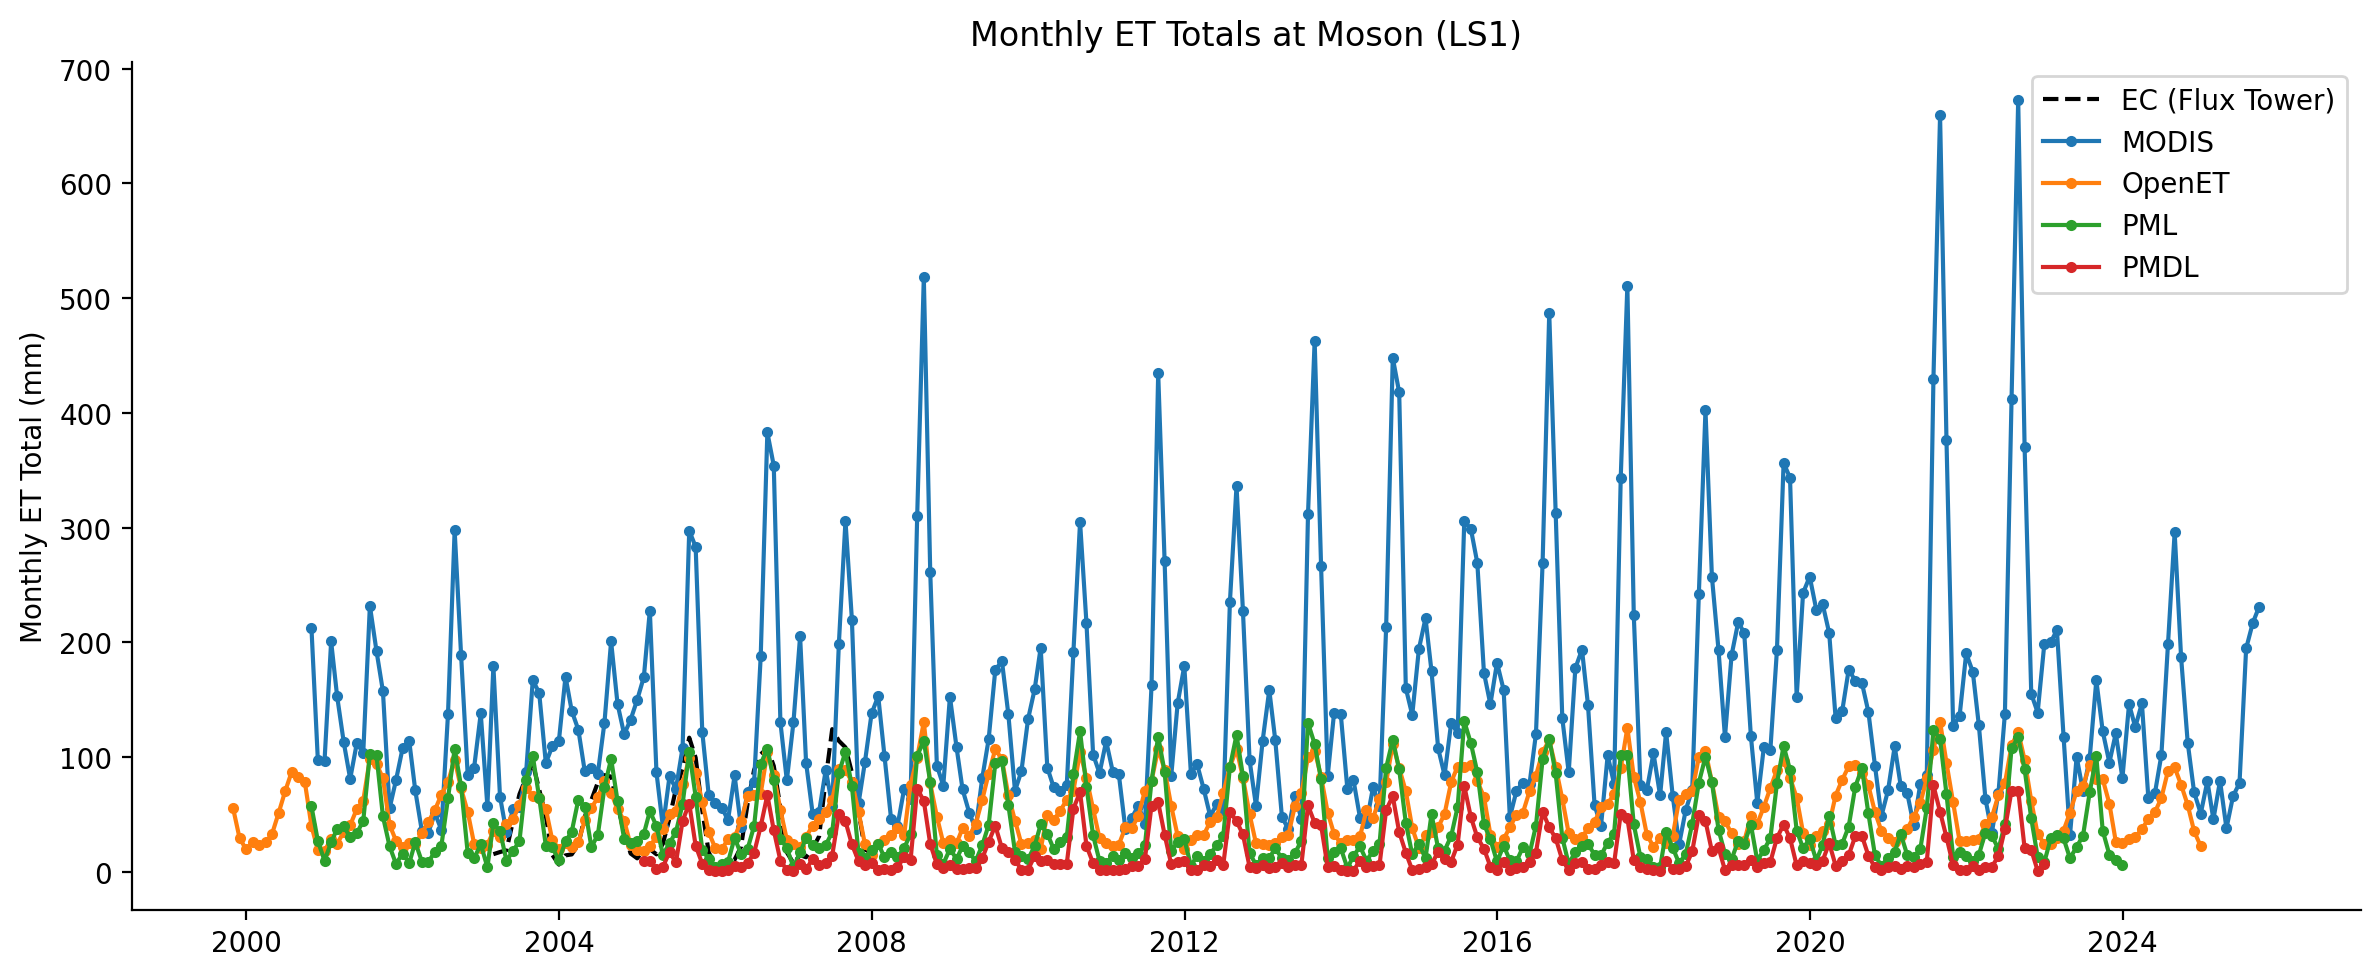

In [23]:
ls1_site = tower_to_site["LS1"]
ls1_products = products["LS1"]
ec_monthly_total = monthly_total_from_rate(ec_daily["LS1"].dropna())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ec_monthly_total.index, ec_monthly_total, color="black", linestyle="--", label="EC (Flux Tower)")
for product in product_order:
    series = ls1_products[product].set_index("Date")["ET"]
    if product == "OpenET":
        monthly_total = series
    elif product == "PMDL":
        monthly_total = monthly_total_from_rate(series)
    else:
        monthly_total = monthly_total_from_periods(series)
    ax.plot(monthly_total.index, monthly_total, marker="o", markersize=3, label=product)
ax.set_ylabel("Monthly ET Total (mm)")
ax.set_title(f"Monthly ET Totals at {ls1_site} (LS1)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()

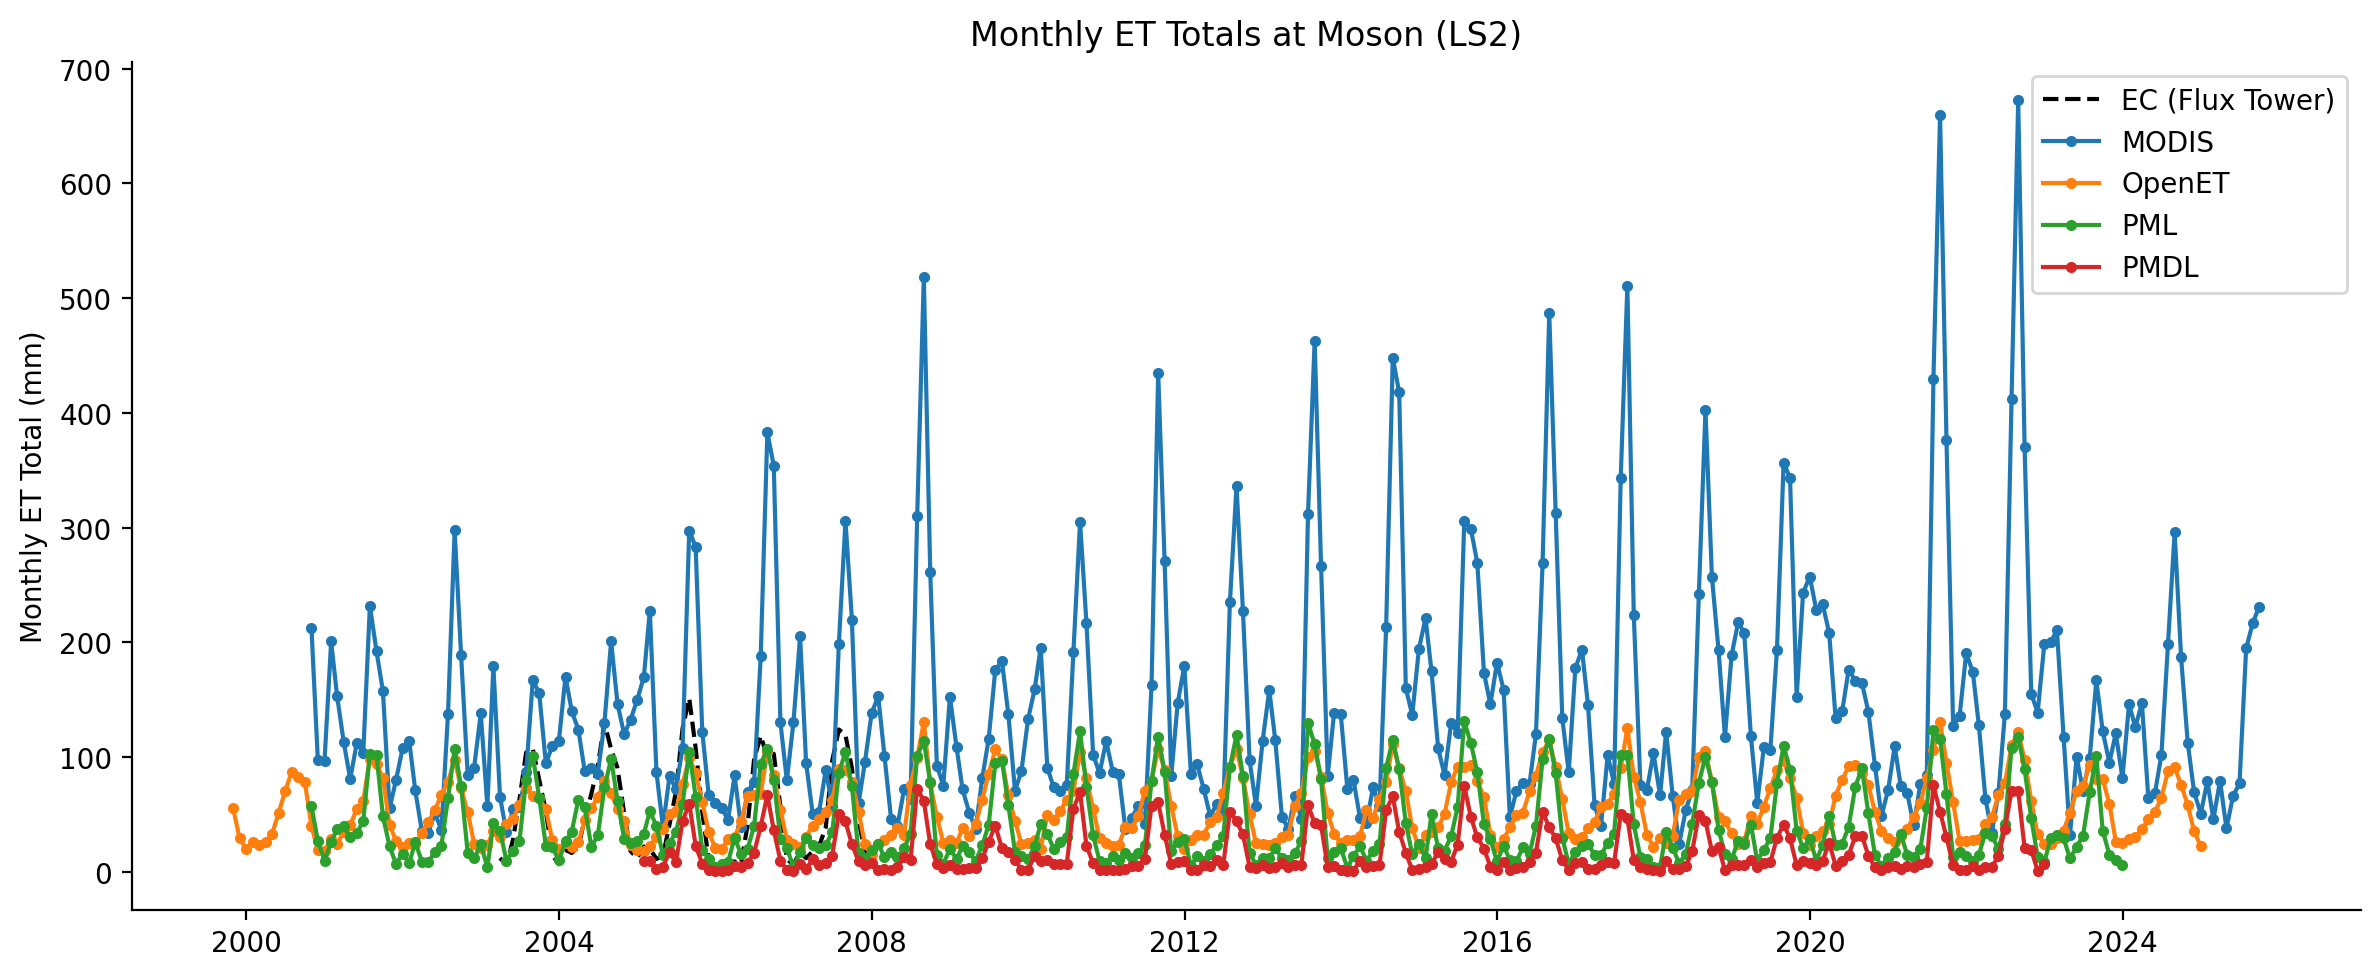

In [24]:
ls2_site = tower_to_site["LS2"]
ls2_products = products["LS2"]
ec_monthly_total = monthly_total_from_rate(ec_daily["LS2"].dropna())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ec_monthly_total.index, ec_monthly_total, color="black", linestyle="--", label="EC (Flux Tower)")
for product in product_order:
    series = ls2_products[product].set_index("Date")["ET"]
    if product == "OpenET":
        monthly_total = series
    elif product == "PMDL":
        monthly_total = monthly_total_from_rate(series)
    else:
        monthly_total = monthly_total_from_periods(series)
    ax.plot(monthly_total.index, monthly_total, marker="o", markersize=3, label=product)
ax.set_ylabel("Monthly ET Total (mm)")
ax.set_title(f"Monthly ET Totals at {ls2_site} (LS2)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()

In [ ]:
START = pd.Timestamp("2004-10-01")
END = pd.Timestamp("2024-09-30")
SEASONS = {1: "Cool-Season Recharge", 2: "Pre-Monsoon Dry", 3: "Monsoon", 4: "Post-Monsoon Recession"}

def season(dates):
    month = dates.month
    return np.select(
        [np.isin(month, [12, 1, 2, 3]), np.isin(month, [4, 5, 6]), np.isin(month, [7, 8, 9])],
        [1, 2, 3],
        default=4,
    )

def completeness(dates, valid_mask):
    dates = pd.DatetimeIndex(dates)
    in_period = (dates >= START) & (dates <= END)
    dates = dates[in_period]
    valid_mask = np.asarray(valid_mask)[in_period]
    seasons = season(dates)
    row = {"Overall": valid_mask.mean() * 100 if len(dates) else np.nan}
    for s, label in SEASONS.items():
        in_season = seasons == s
        row[label] = valid_mask[in_season].mean() * 100 if in_season.any() else np.nan
    return row

In [ ]:
completeness_records = []

full_index = pd.date_range(START, END, freq="D")
for tower in tower_to_site:
    row = completeness(full_index, ec_daily[tower].reindex(full_index).notna())
    row.update({"Source": "EC", "Site": tower})
    completeness_records.append(row)

for site in SITES:
    for product in ["MODIS", "OpenET", "PML"]:
        buf = buffer_table.loc[site, product]
        buf = int(buf) if pd.notna(buf) else BUFFERS[0]
        df = pd.read_csv(DATA / "ET" / f"ET_{site}buffer{buf}{product}.csv")
        df["Date"] = pd.to_datetime(df["Date"])
        row = completeness(df["Date"], df["ET"].notna())
        row.update({"Source": product, "Site": site})
        completeness_records.append(row)

pmdl_all = pd.read_csv(DATA / "Jawad_ET" / "J.csv")
pmdl_all["date"] = pd.to_datetime(pmdl_all["date"])
for site in SITES:
    site_pmdl = pmdl_all[pmdl_all["Site"] == site]
    row = completeness(site_pmdl["date"], site_pmdl["ET"].notna())
    row.update({"Source": "PMDL", "Site": site})
    completeness_records.append(row)

completeness_table = pd.DataFrame(completeness_records).set_index(["Source", "Site"])
completeness_table = completeness_table[["Overall"] + list(SEASONS.values())].round(1)
completeness_table

Overall  Cool-Season Recharge  Pre-Monsoon Dry  \
Source Site                                                                 
EC     CMW                    86.3                  86.3             85.0   
       LS1                    16.2                  16.2             15.0   
       LS2                    15.8                  15.5             14.2   
MODIS  Boquillas             100.0                 100.0            100.0   
OpenET Boquillas               0.0                   0.0              0.0   
PML    Boquillas             100.0                 100.0            100.0   
MODIS  CharlestonMesquite    100.0                 100.0            100.0   
OpenET CharlestonMesquite    100.0                 100.0            100.0   
PML    CharlestonMesquite    100.0                 100.0            100.0   
MODIS  Contention            100.0                 100.0            100.0   
OpenET Contention            100.0                 100.0            100.0   
PML    Contention            100.0                 100.0            100.0   
MODIS  Fairbank              100.0                 100.0            100.0   
OpenET Fairbank              100.0                 100.0            100.0   
PML    Fairbank              100.0                 100.0            100.0   
MODIS  Hereford              100.0                 100.0            100.0   
OpenET Hereford              100.0                 100.0            100.0   
PML    Hereford              100.0                 100.0            100.0   
MODIS  Hunter                100.0                 100.0            100.0   
OpenET Hunter                100.0                 100.0            100.0   
PML    Hunter                100.0                 100.0            100.0   
MODIS  Moson                 100.0                 100.0            100.0   
OpenET Moson                 100.0                 100.0            100.0   
PML    Moson                 100.0                 100.0            100.0   
MODIS  St.David              100.0                 100.0            100.0   
OpenET St.David                0.0                   0.0              0.0   
PML    St.David              100.0                 100.0            100.0   
PMDL   Boquillas             100.0                 100.0            100.0   
       CharlestonMesquite    100.0                 100.0            100.0   
       Contention            100.0                 100.0            100.0   
       Fairbank              100.0                 100.0            100.0   
       Hereford              100.0                 100.0            100.0   
       Hunter                100.0                 100.0            100.0   
       Moson                 100.0                 100.0            100.0   
       St.David              100.0                 100.0            100.0   

                           Monsoon  Post-Monsoon Recession  
Source Site                                                 
EC     CMW                    85.0                    90.0  
       LS1                    15.0                    20.0  
       LS2                    15.0                    19.8  
MODIS  Boquillas             100.0                   100.0  
OpenET Boquillas               0.0                     0.0  
PML    Boquillas             100.0                   100.0  
MODIS  CharlestonMesquite    100.0                   100.0  
OpenET CharlestonMesquite    100.0                   100.0  
PML    CharlestonMesquite    100.0                   100.0  
MODIS  Contention            100.0                   100.0  
OpenET Contention            100.0                   100.0  
PML    Contention            100.0                   100.0  
MODIS  Fairbank              100.0                   100.0  
OpenET Fairbank              100.0                   100.0  
PML    Fairbank              100.0                   100.0  
MODIS  Hereford              100.0                   100.0  
OpenET Hereford              100.0                   100.0  
PML    Hereford   